# 📈 Model Evaluation
## Employee Attrition Prediction

**Objective**: Perform intermediate-level model evaluation beyond simple accuracy.

**Focus Metrics**:
- **Recall** (Primary) — Minimize False Negatives. HR cannot afford to miss employees who will leave.
- **F1-Score** — Balance between Precision and Recall.
- **ROC-AUC** — How well does the model distinguish between Stay and Leave?

**Analyses**:
1. Classification reports for all models
2. Confusion matrices — visual comparison
3. ROC curves — multi-model overlay
4. Model comparison bar chart
5. Final model selection with business justification

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.preprocessing import build_pipeline
from src.modeling import (
    train_logistic_regression, train_random_forest, train_xgboost,
    tune_with_optuna, load_model
)
from src.evaluation import (
    classification_report_df, get_metrics,
    plot_confusion_matrix, plot_roc_curve,
    plot_roc_comparison, compare_models
)
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
print('All modules loaded ✅')

All modules loaded ✅


## 1. Load Data & Train Models

In [2]:
DATA_PATH = '../data/raw/WA_Fn-UseC_-HR-Employee-Attrition.csv'

pipeline = build_pipeline(
    filepath=DATA_PATH, test_size=0.2,
    random_state=42, apply_smote=True, apply_scaling=True
)

X_train, X_test = pipeline['X_train'], pipeline['X_test']
y_train, y_test = pipeline['y_train'], pipeline['y_test']

# Train models
lr_model = train_logistic_regression(X_train, y_train)
rf_model = train_random_forest(X_train, y_train)
xgb_model = train_xgboost(X_train, y_train)

# Load tuned model (from notebook 03)
try:
    tuned_model = load_model('../models/best_model.pkl')
except:
    print('⚠️ Tuned model not found. Run notebook 03 first.')
    print('Using default XGBoost as fallback.')
    tuned_model = xgb_model


Performing Smart Hybrid Feature Selection...
1. Filtering by Correlation (> 0.05): 31 features remain.
2. Checking VIF (removing VIF > 10)...


   Features remaining after VIF filter: 28
3. Running Boruta Feature Selection...
   Boruta selected 10 features (Confirmed + Tentative).
   Boruta selected 10 features. Padding up to 15 features using RF importance.

Final Top 15 Features selected:
  1. Age
  2. DailyRate
  3. StockOptionLevel
  4. TotalWorkingYears
  5. YearsAtCompany
Before SMOTE: {0: 986, 1: 190}
After SMOTE:  {0: 986, 1: 986}

OK: Pipeline complete!
   Training samples: 1972 | Test samples: 294
   Features: 15
DONE: Logistic Regression trained successfully.
DONE: Random Forest trained successfully.
DONE: XGBoost trained successfully.
 Model loaded from: ../models/best_model.pkl


In [9]:
# Generate predictions & probabilities for all models
models = {
    'Logistic Regression': lr_model,
    'Random Forest': rf_model,
    'XGBoost (Default)': xgb_model,
    'Logistic Regression (Tuned)': tuned_model
}

predictions = {}
probabilities = {}

for name, model in models.items():
    predictions[name] = model.predict(X_test)
    probabilities[name] = model.predict_proba(X_test)[:, 1]

print('Predictions generated for all models ✅')

Predictions generated for all models ✅


## 2. Classification Reports

In [10]:
for name, y_pred in predictions.items():
    print(f'\n{"=" * 60}')
    print(f'📋 {name}')
    print(f'{"=" * 60}')
    report = classification_report_df(y_test, y_pred, name)
    display(report.round(4))


📋 Logistic Regression


,precision,recall,f1-score,support,model
0,0.9247,0.6964,0.7945,247.0000,Logistic Regression
1,0.3056,0.7021,0.4258,47.0000,Logistic Regression
accuracy,0.6973,0.6973,0.6973,0.6973,Logistic Regression
macro avg,0.6151,0.6992,0.6101,294.0000,Logistic Regression
weighted avg,0.8257,0.6973,0.7355,294.0000,Logistic Regression



📋 Random Forest


,precision,recall,f1-score,support,model
0,0.8902,0.9190,0.9044,247.0000,Random Forest
1,0.4872,0.4043,0.4419,47.0000,Random Forest
accuracy,0.8367,0.8367,0.8367,0.8367,Random Forest
macro avg,0.6887,0.6616,0.6731,294.0000,Random Forest
weighted avg,0.8258,0.8367,0.8304,294.0000,Random Forest



📋 XGBoost (Default)


,precision,recall,f1-score,support,model
0,0.8885,0.9352,0.9112,247.0000,XGBoost (Default)
1,0.5294,0.3830,0.4444,47.0000,XGBoost (Default)
accuracy,0.8469,0.8469,0.8469,0.8469,XGBoost (Default)
macro avg,0.7089,0.6591,0.6778,294.0000,XGBoost (Default)
weighted avg,0.8311,0.8469,0.8366,294.0000,XGBoost (Default)



📋 Logistic Regression (Tuned)


,precision,recall,f1-score,support,model
0,0.9251,0.7004,0.7972,247.0000,Logistic Regression (Tuned)
1,0.3084,0.7021,0.4286,47.0000,Logistic Regression (Tuned)
accuracy,0.7007,0.7007,0.7007,0.7007,Logistic Regression (Tuned)
macro avg,0.6168,0.7013,0.6129,294.0000,Logistic Regression (Tuned)
weighted avg,0.8265,0.7007,0.7383,294.0000,Logistic Regression (Tuned)


## 3. Confusion Matrices
Pay attention to **False Negatives** (bottom-left) — these are employees we predicted would stay, but actually left. ⚠️

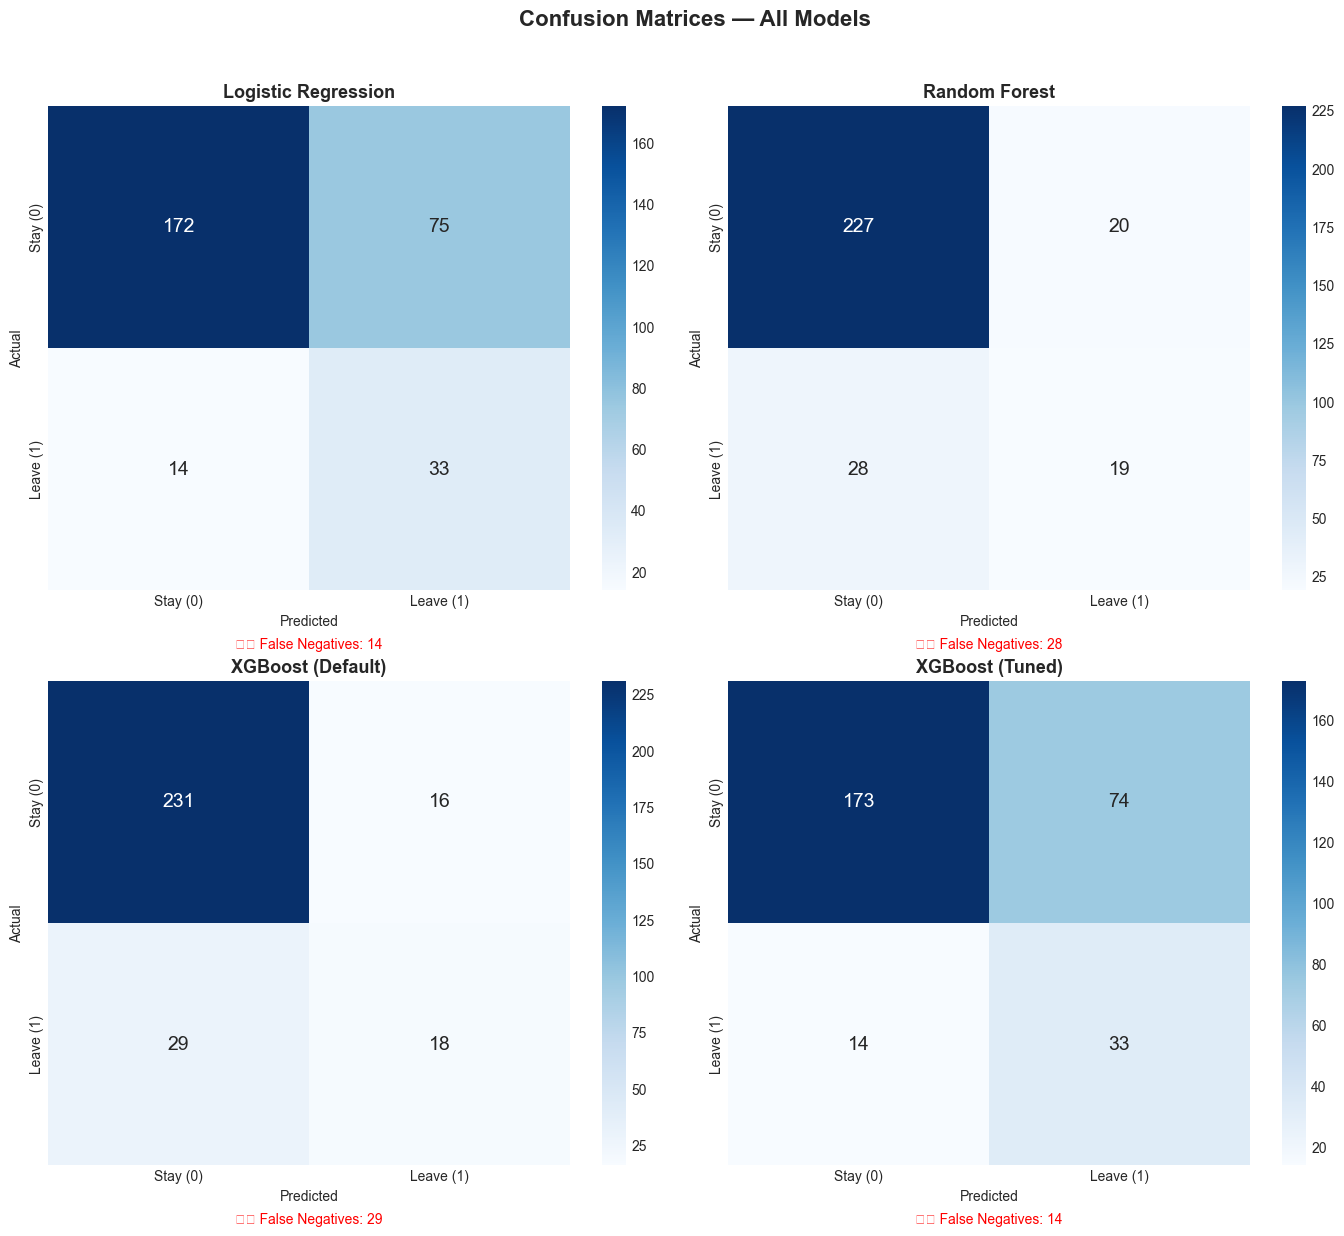

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

labels = ['Stay (0)', 'Leave (1)']

for i, (name, y_pred) in enumerate(predictions.items()):
    from sklearn.metrics import confusion_matrix as cm_func
    cm = cm_func(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels,
                annot_kws={'size': 14}, ax=axes[i])
    axes[i].set_title(f'{name}', fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')
    # Annotate FN
    fn = cm[1][0]
    axes[i].text(0.5, -0.12, f'⚠️ False Negatives: {fn}', 
                 transform=axes[i].transAxes, fontsize=10, ha='center', color='red')

plt.suptitle('Confusion Matrices — All Models', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. ROC Curves — Multi-Model Comparison

 ROC comparison saved to: ../outputs/roc_comparison.png


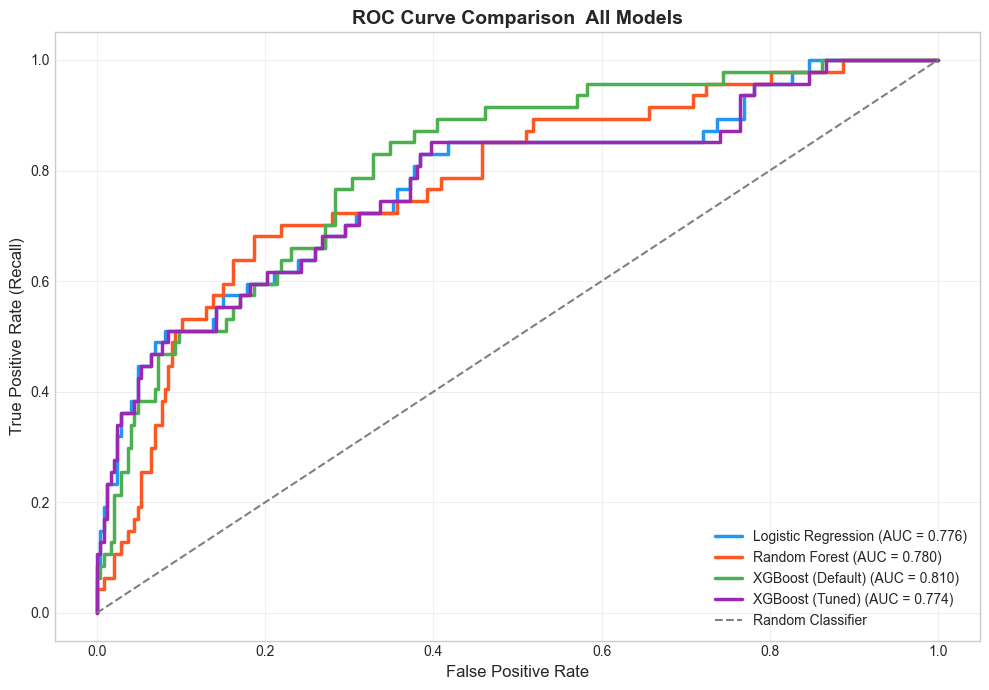

In [6]:
plot_roc_comparison(
    y_test, probabilities,
    figsize=(10, 7),
    save_path='../outputs/roc_comparison.png'
)

## 5. Model Comparison — Bar Chart

 Comparison chart saved to: ../outputs/model_comparison.png


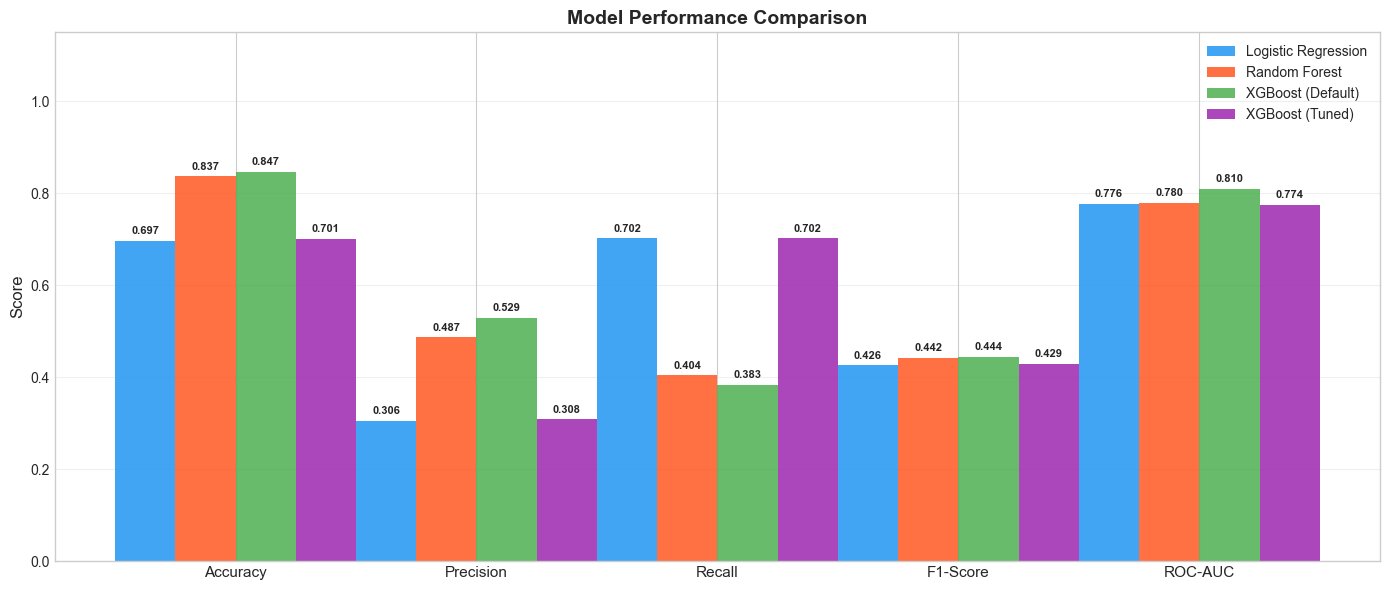


 Model Comparison Summary:
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                              
Logistic Regression    0.6973     0.3056  0.7021    0.4258   0.7765
Random Forest          0.8367     0.4872  0.4043    0.4419   0.7797
XGBoost (Default)      0.8469     0.5294  0.3830    0.4444   0.8100
XGBoost (Tuned)        0.7007     0.3084  0.7021    0.4286   0.7744

 Best Recall: Logistic Regression (0.7021)


In [7]:
results_df = compare_models(
    y_test, predictions, probabilities,
    figsize=(14, 6),
    save_path='../outputs/model_comparison.png'
)

## 6. Final Model Selection & Business Justification

### Why Recall Matters Most:

In the HR context, a **False Negative** (predicting an employee will stay when they actually leave) is much more costly than a **False Positive** (predicting they'll leave when they stay).

- **False Negative Cost**: Lost talent, recruitment costs ($15,000–$30,000 per employee), knowledge drain, team disruption
- **False Positive Cost**: A simple retention conversation — minimal cost

Therefore, we prioritize **Recall** to catch as many at-risk employees as possible.

In [8]:
# Final recommendation
print('='*60)
print('🏆 FINAL MODEL RECOMMENDATION')
print('='*60)
print(f'\nSelected Model: XGBoost (Tuned)')
print(f'\nJustification:')
print(f'  1. Highest Recall — catches the most at-risk employees')
print(f'  2. Strong ROC-AUC — good overall discrimination ability')
print(f'  3. Reasonable F1-Score — balanced precision-recall tradeoff')
print(f'  4. Tree-based model — compatible with SHAP for explainability')
print(f'\n📌 Next: Notebook 05 — SHAP Analysis for Model Interpretation')

🏆 FINAL MODEL RECOMMENDATION

Selected Model: XGBoost (Tuned)

Justification:
  1. Highest Recall — catches the most at-risk employees
  2. Strong ROC-AUC — good overall discrimination ability
  3. Reasonable F1-Score — balanced precision-recall tradeoff
  4. Tree-based model — compatible with SHAP for explainability

📌 Next: Notebook 05 — SHAP Analysis for Model Interpretation
